In [3]:
import numpy as np
import matplotlib.pyplot as plt

from pde.coeff_function import coeff
from pde.diffusion_1d import Diffusion1D

from tree.tree import Tree
from tree_tensor.tree_tensor import TreeBasedTensor
from tree_cross.tree_cross import TreeCross
from tree.tree_util import balanced_binary_tupletree, linear_tupletree
from tree_als_cross.tree_als_cross import TreeALSCross

### PDE test

Solve the PDE using P1 finite elements for a random parameter

Text(0, 0.5, 'A')

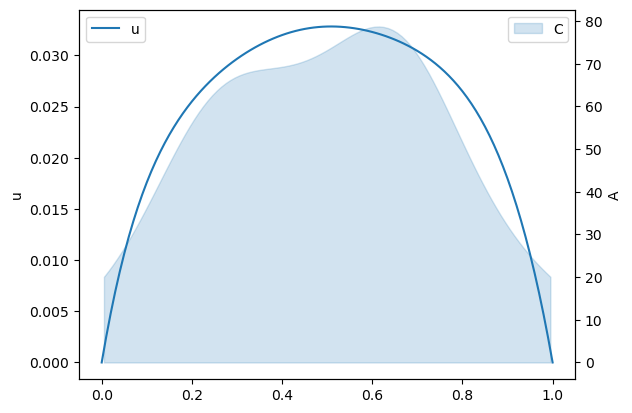

In [4]:
Nx = 100    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 5 # number of parameters for diffusion coeff
n_param = n_a_param 
offset = 3   # parameter mean
var = 4       # 'variance' of the parameters
v_min, v_max = -10, 10

# get random params
rng = np.random.default_rng()
y = rng.uniform(0, Ny-1, n_a_param)
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

cfun = coeff(Nx, Ny, offset, var)

C_true = cfun(X)

PDE_fun = Diffusion1D(Nx)

U = PDE_fun.solve([C_true.reshape(-1,1), np.ones((1,1))], [np.ones((1,1))])
U = np.ravel(U[0])

fig, ax = plt.subplots()
ax2 = ax.twinx()

x = np.arange(Nx+1) / Nx
midpoints = (np.arange(Nx) + 0.5) / Nx
p = ax.plot(x, U, label='u')
ax2.fill_between((np.arange(len(C_true)) + 0.5) / (len(C_true)), C_true, alpha=0.2, color=p[0].get_color(), label='C')

ax.set_ylabel('u')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax2.set_ylabel('A')

### Get HT approx of coefficient

In [5]:

tol = 1e-3
param_shape = tuple([Ny] * n_param)

tree = Tree.from_tupletree(balanced_binary_tupletree(n_param))
# tree = Tree.from_tupletree((0,(1,2)))
tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

cross = TreeCross(C_a)
cross.run(cfun, n_iter=50, eps=tol, kickrank=1, verbose=True)
C_a.round(tol=tol)
C_a.print()

[10] (root) 
 + [0] (dim 0)
 + [9] 
    + [3] 
    |  + [1] (dim 1)
    |  + [2] (dim 2)
    + [8] 
       + [4] (dim 3)
       + [7] 
          + [5] (dim 4)
          + [6] (dim 5)

swp:  1/50 f_evals=991 self.max_dx=3.33e+04
swp:  2/50 f_evals=2377 self.max_dx=9.12e+01
swp:  3/50 f_evals=4740 self.max_dx=2.41e+01
swp:  4/50 f_evals=8590 self.max_dx=7.89e-01
swp:  5/50 f_evals=14438 self.max_dx=1.65e-01
swp:  6/50 f_evals=20447 self.max_dx=2.80e-02
swp:  7/50 f_evals=26481 self.max_dx=1.00e-02
swp:  8/50 f_evals=32585 self.max_dx=1.30e-02
swp:  9/50 f_evals=38899 self.max_dx=8.30e-03
swp: 10/50 f_evals=45453 self.max_dx=1.05e-02
swp: 11/50 f_evals=51798 self.max_dx=9.46e-03
swp: 12/50 f_evals=57792 self.max_dx=7.47e-03
swp: 13/50 f_evals=63896 self.max_dx=1.13e-02
swp: 14/50 f_evals=70210 self.max_dx=8.20e-03
swp: 15/50 f_evals=76764 self.max_dx=1.05e-02
swp: 16/50 f_evals=83109 self.max_dx=9.46e-03
swp: 17/50 f_evals=89103 self.max_dx=7.47e-03
swp: 18/50 f_evals=95207 self.max_dx=1.

### Test TT approx

Compare TT approx of coefficient $A$ vs the true coefficient $A$ for the random parameter sample from above

RMS l2 err = 4.73e-02


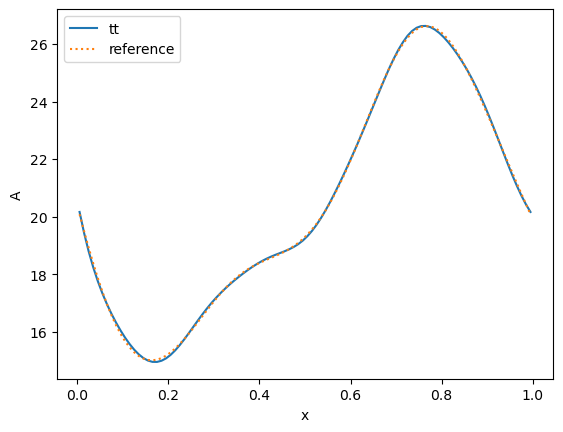

In [6]:
N_MC = 500

def RMS(x, **kwargs):
  return np.sqrt(np.mean(np.square(x), **kwargs))

errs = np.zeros(N_MC)
for i in range(N_MC):
  # eval TT-approx of coeff
  y = rng.integers(0, Ny, n_a_param)
  C_eval = np.ravel(C_a[:, *y])

  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
  C_true = cfun(X)

  errs[i] = RMS(C_eval-C_true)

print(f'RMS l2 err = {RMS(errs):.2e}')

fig, ax = plt.subplots()

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [7]:
# helper tensor that is constant 1
C_const = TreeBasedTensor.ones(tree, (1,) + param_shape)
C_const2 = TreeBasedTensor.ones(tree, (1,) + param_shape)

### ALS-cross test

In [8]:
test = TreeALSCross(
  [C_a, C_const],
  [C_const],
  PDE_fun,
  rinit=0,
  verbose=1,
  kickrank=5
  )

test.run(n_iter=3)

u = test.get_tensor()

Init finished
= swp=0
= swp=0 finished, max_dx=1.48e+04
= swp=1
= swp=1 finished, max_dx=1.39e-02
= swp=2
= swp=2 finished, max_dx=9.85e-04


### Test ALS-cross accuracy

Compare ALS cross approximation vs PDE solution for a random sample

RMS l2 err = 6.76e-04
RMS l2 err with approx coeff = 4.20e-04
example
l2 err = 1.37e-03
l2 err to approx coeff = 1.17e-03


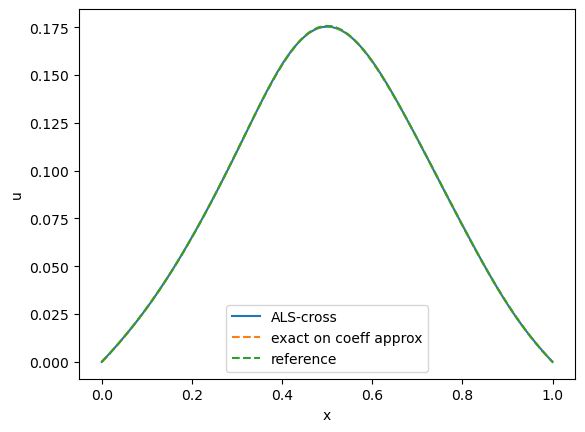

In [9]:
N_MC = 500
err = 0
err_c = 0

for n in range(N_MC):
  # get random parameter
  y = rng.integers(0, Ny, n_param)
  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

  C_a_true = cfun(X) # compute true coeff

  U = PDE_fun.solve([C_a_true.reshape(-1,1), np.zeros((1,1))], [np.zeros((1,1))]) # solve PDE
  U = np.ravel(U)

  # eval ALS-cross
  U_eval = np.ravel(u[:, *y])
  err += np.sum(np.square(U - U_eval))

  C_eval = np.ravel(C_a[:, *y[:]])
  U_c = PDE_fun.solve([C_eval.reshape(-1,1), np.zeros((1,1))], [np.zeros((1,1))]) # solve PDE
  U_c = np.ravel(U_c)
  err_c += np.sum(np.square(U - U_c))

err = np.sqrt(err / N_MC)
err_c = np.sqrt(err_c / N_MC)

print(f'RMS l2 err = {err:.2e}')
print(f'RMS l2 err with approx coeff = {err_c:.2e}')

fig, ax = plt.subplots()

x = np.arange(0, Nx+1) / Nx
ax.plot(x, U_eval, label='ALS-cross')
ax.plot(x, U_c, ls='dashed', label='exact on coeff approx')
ax.plot(x, U, ls='dashed', label='reference')
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.legend()

print('example')
print(f'l2 err = {np.linalg.norm(U-U_eval):.2e}')
print(f'l2 err to approx coeff = {np.linalg.norm(U_c-U_eval):.2e}')